In [7]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

def load_text_data(filepath):
    with h5py.File(filepath, 'r') as f:
        # Load inputs and targets (labels) and subtract 1 for 0-based indexing
        trainx = np.array(f['trainx'], dtype=np.int32) - 1
        traind = np.array(f['traind'], dtype=np.int32) - 1
        valx = np.array(f['valx'], dtype=np.int32) - 1
        vald = np.array(f['vald'], dtype=np.int32) - 1
        testx = np.array(f['testx'], dtype=np.int32) - 1
        testd = np.array(f['testd'], dtype=np.int32) - 1
        
    # Squeeze targets to ensure they are 1D arrays for indexing
    return trainx, traind.squeeze(), valx, vald.squeeze(), testx, testd.squeeze()

class TrigramPredictorNN:
    def __init__(self, vocab_size, D, P):
        self.vocab_size = vocab_size
        self.D = D
        self.P = P
        
        # Initialize weights and biases as random Gaussian variables of std 0.01 
        self.R = np.random.randn(vocab_size, D) * 0.01 
        self.W1 = np.random.randn(3 * D, P) * 0.01
        self.b1 = np.random.randn(1, P) * 0.01
        self.W2 = np.random.randn(P, vocab_size) * 0.01
        self.b2 = np.random.randn(1, vocab_size) * 0.01
        
        # Initialize velocities for momentum 
        self.v_R = np.zeros_like(self.R)
        self.v_W1 = np.zeros_like(self.W1)
        self.v_b1 = np.zeros_like(self.b1)
        self.v_W2 = np.zeros_like(self.W2)
        self.v_b2 = np.zeros_like(self.b2)

    def sigmoid(self, z):
        # Clip z to prevent overflow
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))
    
    def sigmoid_derivative(self, a):
        return a * (1.0 - a)
    
    def softmax(self, z):
        # Subtract max for numerical stability
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def forward(self, X):
        # X is shape (batch_size, 3) containing word indices
        # Embedding lookup: output shape is (batch_size, 3, D)
        self.embedded = self.R[X] 
        
        # Flatten embeddings for the hidden layer: (batch_size, 3 * D)
        self.flattened_emb = self.embedded.reshape(X.shape[0], -1)
        
        # Hidden layer with Sigmoid 
        self.Z1 = np.dot(self.flattened_emb, self.W1) + self.b1
        self.A1 = self.sigmoid(self.Z1)
        
        # Output layer with Softmax 
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        
        return self.A2
    
    def compute_cross_entropy(self, A2, Y):
        m = Y.shape[0]
        # Clip predictions to prevent log(0)
        A2_clipped = np.clip(A2, 1e-9, 1 - 1e-9)
        # Select the probability assigned to the true class
        correct_class_probs = A2_clipped[np.arange(m), Y]
        return -np.mean(np.log(correct_class_probs))
    
    def backward(self, X, Y, learning_rate, momentum):
        m = X.shape[0]
        
        # Gradient of Softmax + Cross Entropy
        dZ2 = self.A2.copy()
        dZ2[np.arange(m), Y] -= 1
        dZ2 /= m
        
        # Hidden to Output Gradients
        dW2 = np.dot(self.A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)
        
        # Hidden Layer Gradients
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.sigmoid_derivative(self.A1)
        
        dW1 = np.dot(self.flattened_emb.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)
        
        # Embedding Layer Gradients
        d_flattened_emb = np.dot(dZ1, self.W1.T)
        d_embedded = d_flattened_emb.reshape(m, 3, self.D)
        
        # We need to accumulate the gradients for the specific word embeddings used
        dR = np.zeros_like(self.R)
        np.add.at(dR, X, d_embedded)
        
        # Apply Momentum updates 
        self.v_W2 = momentum * self.v_W2 + learning_rate * dW2
        self.v_b2 = momentum * self.v_b2 + learning_rate * db2
        self.v_W1 = momentum * self.v_W1 + learning_rate * dW1
        self.v_b1 = momentum * self.v_b1 + learning_rate * db1
        self.v_R = momentum * self.v_R + learning_rate * dR
        
        # Update weights
        self.W2 -= self.v_W2
        self.b2 -= self.v_b2
        self.W1 -= self.v_W1
        self.b1 -= self.v_b1
        self.R -= self.v_R

    def train(self, X_train, Y_train, X_val, Y_val, epochs, batch_size, learning_rate, momentum):
        history = {'train_loss': [], 'val_loss': []}
        num_samples = X_train.shape[0]
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(epochs):
            indices = np.random.permutation(num_samples)
            X_train_shuffled = X_train[indices]
            Y_train_shuffled = Y_train[indices]
            
            for i in range(0, num_samples, batch_size):
                X_batch = X_train_shuffled[i:i+batch_size]
                Y_batch = Y_train_shuffled[i:i+batch_size]
                
                self.forward(X_batch)
                self.backward(X_batch, Y_batch, learning_rate, momentum)
            
            # Evaluate after epoch
            train_preds = self.forward(X_train)
            val_preds = self.forward(X_val)
            
            train_loss = self.compute_cross_entropy(train_preds, Y_train)
            val_loss = self.compute_cross_entropy(val_preds, Y_val)
            
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")
            
            # Early stopping based on validation data 
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= 3: # Stop if validation loss doesn't improve for 3 epochs
                    print(f"Early stopping triggered at epoch {epoch+1}.")
                    break
                    
        return history


--- Training with D=32, P=256 ---
Epoch 1/50 - Train Loss: 4.0158 - Val Loss: 4.0216
Epoch 2/50 - Train Loss: 3.3104 - Val Loss: 3.3201
Epoch 3/50 - Train Loss: 3.0662 - Val Loss: 3.0756
Epoch 4/50 - Train Loss: 2.9330 - Val Loss: 2.9476
Epoch 5/50 - Train Loss: 2.8453 - Val Loss: 2.8688
Epoch 6/50 - Train Loss: 2.7866 - Val Loss: 2.8170
Epoch 7/50 - Train Loss: 2.7322 - Val Loss: 2.7698
Epoch 8/50 - Train Loss: 2.6863 - Val Loss: 2.7318
Epoch 9/50 - Train Loss: 2.6561 - Val Loss: 2.7097
Epoch 10/50 - Train Loss: 2.6147 - Val Loss: 2.6752
Epoch 11/50 - Train Loss: 2.5848 - Val Loss: 2.6523
Epoch 12/50 - Train Loss: 2.5635 - Val Loss: 2.6402
Epoch 13/50 - Train Loss: 2.5386 - Val Loss: 2.6263
Epoch 14/50 - Train Loss: 2.5252 - Val Loss: 2.6183
Epoch 15/50 - Train Loss: 2.5048 - Val Loss: 2.6057
Epoch 16/50 - Train Loss: 2.4858 - Val Loss: 2.5954
Epoch 17/50 - Train Loss: 2.4672 - Val Loss: 2.5861
Epoch 18/50 - Train Loss: 2.4505 - Val Loss: 2.5739
Epoch 19/50 - Train Loss: 2.4477 - Val

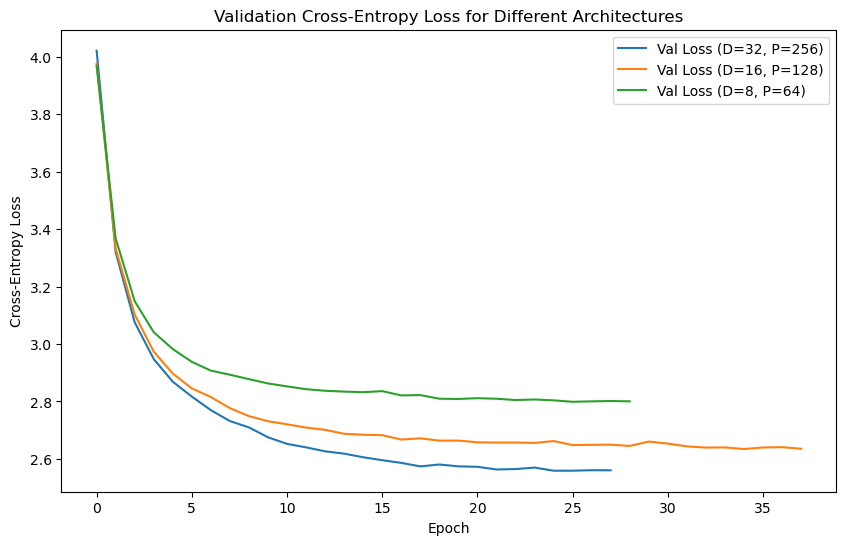

In [9]:
# Assuming data is loaded
trainx, traind, valx, vald, testx, testd = load_text_data('assign2_data2.h5')

vocab_size = 250
batch_size = 200 
learning_rate = 0.15 
momentum = 0.85 
max_epochs = 50 

configs = [(32, 256), (16, 128), (8, 64)] # (D, P) pairs 
trained_models = {}

plt.figure(figsize=(10, 6))

for D, P in configs:
    print(f"\n--- Training with D={D}, P={P} ---")
    model = TrigramPredictorNN(vocab_size, D, P)
    hist = model.train(trainx, traind, valx, vald, max_epochs, batch_size, learning_rate, momentum)
    
    trained_models[(D, P)] = model
    
    plt.plot(hist['val_loss'], label=f'Val Loss (D={D}, P={P})')

plt.title('Validation Cross-Entropy Loss for Different Architectures')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.show()

In [13]:
import h5py

# Load the vocabulary words from the h5 file and decode them
with h5py.File('assign2_data2.h5', 'r') as f:
    # Decode byte strings to regular python strings
    vocab_words = [word.decode('utf-8') for word in f['words'][:]]

# Assuming 'trained_models' from Part (a) is still in memory, 
# let's select the model with the most capacity (D=32, P=256)
best_model = trained_models[(32, 256)]

# 1. Pick 5 random sample indices from the test data
np.random.seed(42) # For reproducibility
num_test_samples = testx.shape[0]
sample_indices = np.random.choice(num_test_samples, 5, replace=False)

sample_trigrams = testx[sample_indices]
actual_fourth_words = testd[sample_indices]

# 2. Generate predictions for the fourth word using the trained model
predictions = best_model.forward(sample_trigrams)

# 3. List the top 10 candidates for each of the 5 samples with ACTUAL WORDS
print("Top 10 Predictions for 5 Sample Trigrams:\n" + "="*55)

for i in range(5):
    trigram_ids = sample_trigrams[i]
    actual_word_id = actual_fourth_words[i]
    probs = predictions[i]
    
    # Translate the trigram IDs to words
    trigram_words = [vocab_words[idx] for idx in trigram_ids]
    actual_word_str = vocab_words[actual_word_id]
    
    # Get indices of the top 10 probabilities in descending order
    top_10_indices = np.argsort(probs)[::-1][:10]
    top_10_probs = probs[top_10_indices]
    
    print(f"Sample {i+1}:")
    print(f"  Input Trigram: '{trigram_words[0]} {trigram_words[1]} {trigram_words[2]}'")
    print(f"  Actual 4th Word: '{actual_word_str}'")
    print(f"  Top 10 Predicted Candidates:")
    
    for rank, (idx, prob) in enumerate(zip(top_10_indices, top_10_probs)):
        predicted_word = vocab_words[idx]
        # Mark the correct prediction with an asterisk if it's in the top 10
        marker = " <--- ACTUAL" if idx == actual_word_id else ""
        print(f"    {rank+1:2d}. {predicted_word:15s} | Prob: {prob:.4f}{marker}")
    print("-" * 55)

Top 10 Predictions for 5 Sample Trigrams:
Sample 1:
  Input Trigram: 'not next season'
  Actual 4th Word: ','
  Top 10 Predicted Candidates:
     1. .               | Prob: 0.8943
     2. ,               | Prob: 0.0440 <--- ACTUAL
     3. and             | Prob: 0.0149
     4. ?               | Prob: 0.0133
     5. 's              | Prob: 0.0067
     6. is              | Prob: 0.0033
     7. for             | Prob: 0.0024
     8. to              | Prob: 0.0021
     9. ;               | Prob: 0.0018
    10. now             | Prob: 0.0017
-------------------------------------------------------
Sample 2:
  Input Trigram: 'do not work'
  Actual 4th Word: 'as'
  Top 10 Predicted Candidates:
     1. .               | Prob: 0.3985
     2. for             | Prob: 0.0980
     3. ,               | Prob: 0.0829
     4. out             | Prob: 0.0784
     5. that            | Prob: 0.0459
     6. with            | Prob: 0.0388
     7. at              | Prob: 0.0321
     8. well            | Prob: 